In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# Standard scaler
thier are mainly three things in it :-
- fit to calculate parameters
- transform to get final scaled values
- convert to dataframe

In [4]:
numeric = ['SeniorCitizen','tenure','MonthlyCharges']
df[numeric]

,SeniorCitizen,tenure,MonthlyCharges
0,0,1,29.85
1,0,34,56.95
2,0,2,53.85
3,0,45,42.30
4,0,2,70.70
...,...,...,...
7038,0,24,84.80
7039,0,72,103.20
7040,0,11,29.60
7041,1,4,74.40


In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled = scaler.fit(df[numeric])
scaled

StandardScaler()

In [6]:
scaled_data = scaled.transform(df[numeric])
scaled_data
df[['s1','s2','s3']] = scaled.transform(df[numeric])

In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,s1,s2,s3
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,-0.439916,-1.277445,-1.160323
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.5,No,-0.439916,0.066327,-0.259629
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,-0.439916,-1.236724,-0.362660
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,-0.439916,0.514251,-0.746535
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,-0.439916,-1.236724,0.197365


In [8]:
scaled_df = pd.DataFrame(scaled_data,columns=numeric)
scaled_df

,SeniorCitizen,tenure,MonthlyCharges
0,-0.439916,-1.277445,-1.160323
1,-0.439916,0.066327,-0.259629
2,-0.439916,-1.236724,-0.362660
3,-0.439916,0.514251,-0.746535
4,-0.439916,-1.236724,0.197365
...,...,...,...
7038,-0.439916,-0.340876,0.665992
7039,-0.439916,1.613701,1.277533
7040,-0.439916,-0.870241,-1.168632
7041,2.273159,-1.155283,0.320338


<Axes: xlabel='tenure', ylabel='MonthlyCharges'>

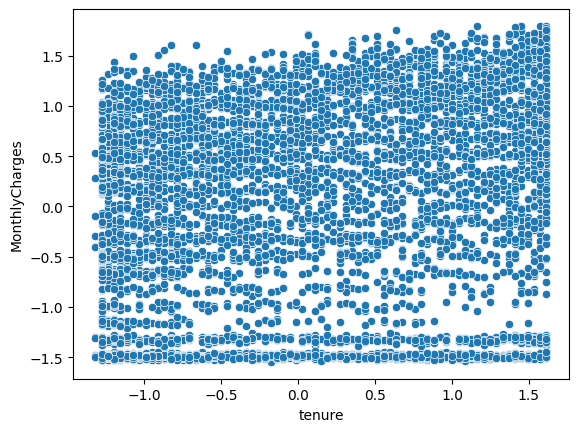

In [9]:
sns.scatterplot(x='tenure',y='MonthlyCharges',data=scaled_df)

<Axes: xlabel='tenure', ylabel='MonthlyCharges'>

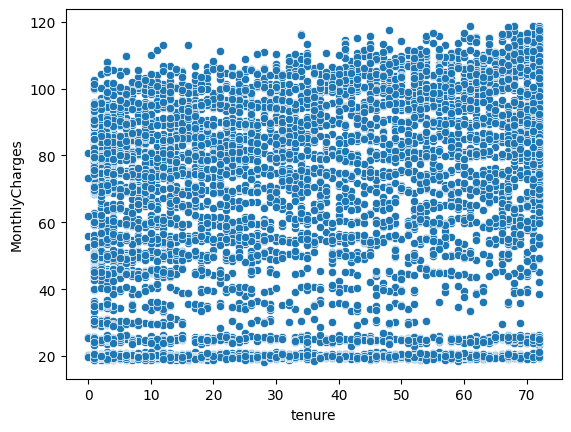

In [10]:
sns.scatterplot(x='tenure',y='MonthlyCharges',data=df)

# MinMax Scaling (Normalization)

In [11]:
from sklearn.preprocessing import MinMaxScaler
mnx = MinMaxScaler()
mn_scaled = mnx.fit(df[numeric])
mn_scaled

MinMaxScaler()

In [12]:
mn_scaled_data = mn_scaled.transform(df[numeric])
mn_scaled_data
mn_scaled_data = pd.DataFrame(mn_scaled_data,columns=numeric)

mn_scaled_data.head()

,SeniorCitizen,tenure,MonthlyCharges
0,0.0,0.013889,0.115423
1,0.0,0.472222,0.385075
2,0.0,0.027778,0.354229
3,0.0,0.625000,0.239303
4,0.0,0.027778,0.521891


<Axes: xlabel='tenure', ylabel='MonthlyCharges'>

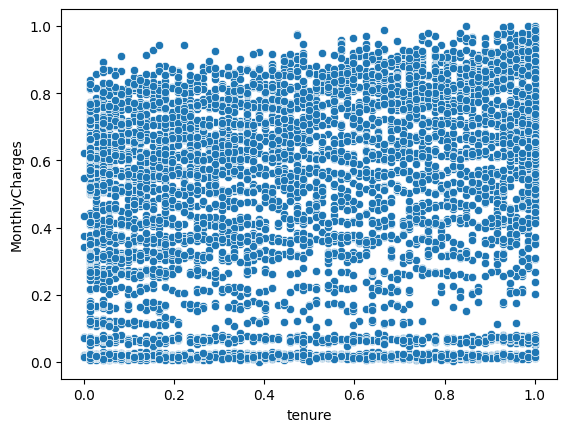

In [13]:
sns.scatterplot(x='tenure',y='MonthlyCharges',data=mn_scaled_data)

<Axes: xlabel='tenure', ylabel='MonthlyCharges'>

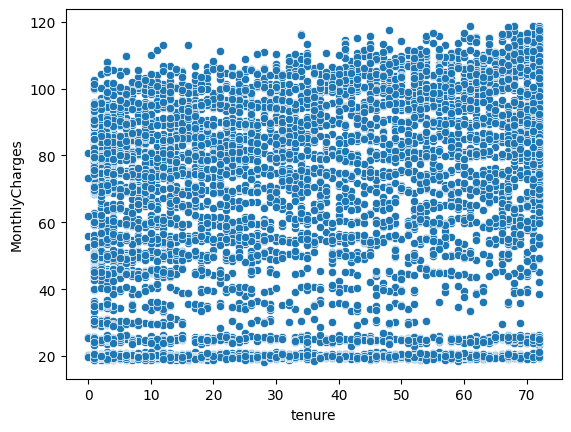

In [14]:
sns.scatterplot(x='tenure',y='MonthlyCharges',data=df)


# Robust scaler
since we don't have a feature which has certain outliers, we can't use robust scaler for that matter

Formula: (x - median) / IQR

In [15]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges']

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

<Axes: xlabel='tenure', ylabel='TotalCharges'>

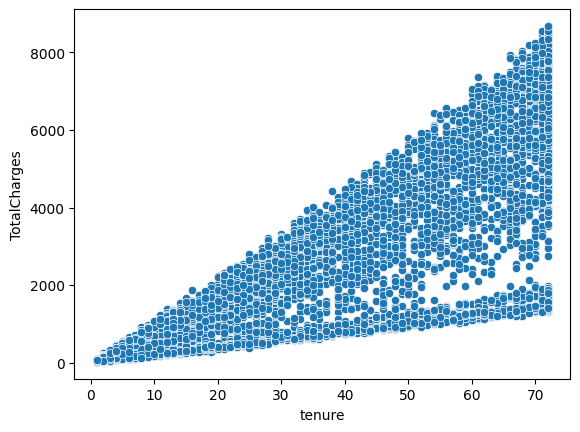

In [16]:
sns.scatterplot(x='tenure',y='TotalCharges',data=df)

# Encoding
- Ordinal Encoding
- Label Encoding
- One hot encoding

In [17]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,s1,s2,s3
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,-0.439916,-1.277445,-1.160323
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,-0.439916,0.066327,-0.259629


In [18]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

# Ordinal Encoder
here also we do same things, fit -> transform -> Dataframe or store that values in a column
but in ordinal encoding you have to first define the order of the categories.

In [19]:
from sklearn.preprocessing import OrdinalEncoder
# oe = OrdinalEncoder()

In [20]:
enc = OrdinalEncoder(categories=[['Month-to-month','One year','Two year']])
df['Contract_encoded'] = enc.fit_transform(df[['Contract']])
df[['Contract','Contract_encoded']].sample()

,Contract,Contract_encoded
2026,One year,1.0


# Label encoding
only used in target variable

In [21]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,s1,s2,s3,Contract_encoded
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,-0.439916,-1.277445,-1.160323,0.0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,One year,No,Mailed check,56.95,1889.50,No,-0.439916,0.066327,-0.259629,1.0


In [22]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [23]:
from sklearn.preprocessing import LabelEncoder

In [24]:
le = LabelEncoder()

In [25]:
enc2 = le.fit(df['Churn'])
enc2

LabelEncoder()

In [26]:
enc2_data = enc2.transform(df['Churn'])
enc2_data

array([0, 0, 1, ..., 0, 1, 0])

In [27]:
enc2_df = pd.DataFrame(enc2_data,columns=['Churn'])
enc2_df.value_counts()

Churn
0        5174
1        1869
Name: count, dtype: int64

# One Hot Encoding

In [28]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,s1,s2,s3,Contract_encoded
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,-0.439916,-1.277445,-1.160323,0.0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,One year,No,Mailed check,56.95,1889.50,No,-0.439916,0.066327,-0.259629,1.0


In [29]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [30]:
pd.get_dummies(df,columns=['InternetService']).head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,s1,s2,s3,Contract_encoded,InternetService_DSL,InternetService_Fiber optic,InternetService_No
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,No,Yes,...,29.85,29.85,No,-0.439916,-1.277445,-1.160323,0.0,True,False,False
1,5575-GNVDE,Male,0,No,No,34,Yes,No,Yes,No,...,56.95,1889.50,No,-0.439916,0.066327,-0.259629,1.0,True,False,False
2,3668-QPYBK,Male,0,No,No,2,Yes,No,Yes,Yes,...,53.85,108.15,Yes,-0.439916,-1.236724,-0.362660,0.0,True,False,False


In [31]:
df.drop(columns=['s1','s2','s3'], inplace=True)
# don't run it again, cuz it will show error

In [32]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Contract_encoded
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0.0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,1.0


In [33]:
from sklearn.preprocessing import OneHotEncoder

In [34]:
ohe = OneHotEncoder()
# ohe = OneHotEncoder(drop='first',dtype=np.int32)

ohe_data = ohe.fit_transform(df[['InternetService']])
ohe_data.toarray()

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       ...,
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.]])